# Laboratorio 4 — Validación y pipelines

Evaluar un modelo es **estimar el error que va a cometer sobre datos que no vio**, y ese
error depende tanto del modelo como de la preparación que se le aplicó a los datos. Este
laboratorio recorre las tres piezas:

1. **Hold-out** — apartar una parte de los datos antes de entrenar.
2. **Validación cruzada $K$-fold** — repartir los datos en $K$ partes y validar $K$ veces.
3. **`Pipeline` y `ColumnTransformer`** — encapsular imputación, codificación, escalado y
   modelo en un único objeto, de modo que la preparación se ajuste siempre sobre la parte
   de entrenamiento y nunca sobre el conjunto completo.

Hay **dieciséis ejercicios** intercalados. Cada uno se resuelve en pocas líneas.

Todo corre **sin archivos externos**: el conjunto de datos viene con `scikit-learn`.

## 0. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams.update({"figure.figsize": (8, 3.5), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=3, suppress=True)

### Los datos

`load_diabetes` es un conjunto de regresión que viene incluido en `scikit-learn`: 442
pacientes, 10 variables clínicas y una respuesta numérica que mide la progresión de la
enfermedad al cabo de un año. **No hay faltantes ni categóricas**, de modo que se puede
modelar directamente.

In [2]:
datos = load_diabetes()
X, y = datos.data, datos.target

print(f"X: {X.shape}   ->  {X.shape[0]} observaciones, {X.shape[1]} atributos")
print(f"y: {y.shape}")
print(f"\nAtributos: {list(datos.feature_names)}")
print(f"\nRespuesta: media = {y.mean():.1f}, desvío = {y.std(ddof=1):.1f}, "
      f"rango = [{y.min():.0f}, {y.max():.0f}]")

X: (442, 10)   ->  442 observaciones, 10 atributos
y: (442,)

Atributos: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Respuesta: media = 152.1, desvío = 77.1, rango = [25, 346]


Esta versión de los atributos **viene estandarizada de fábrica**: cada columna está centrada
y llevada a una escala común. Es una particularidad de este conjunto, no la regla, y es
justamente lo que la sección 3 deja de suponer.

Conviene retener el **desvío de la respuesta**: es el error que cometería un modelo que
predijera siempre la media. Cualquier modelo útil tiene que quedar por debajo.

In [3]:
def rmse(y_real, y_predicho) -> float:
    """Raíz del error cuadrático medio, en las unidades de la respuesta."""
    return float(np.sqrt(mean_squared_error(y_real, y_predicho)))


print(f"Error de predecir siempre la media: {rmse(y, np.full_like(y, y.mean())):.2f}")

Error de predecir siempre la media: 77.01


---

# 1. Hold-out

Se aparta un porcentaje de las observaciones **antes de entrenar**, se ajusta el modelo con
el resto y se mide el error sobre lo apartado.

### 1.1 Qué hace `train_test_split`

Antes de usarlo sobre datos reales conviene verlo sobre diez observaciones numeradas, para
entender **exactamente qué devuelve**.

In [5]:
ejemplo = np.arange(10)          # observaciones 0 a 9
print("Todas:", ejemplo)

entrena, prueba = train_test_split(ejemplo, test_size=0.3, random_state=42)
print("Entrenamiento:", entrena, f"  ({len(entrena)} observaciones)")
print("Prueba       :", prueba, f"  ({len(prueba)} observaciones)")

Todas: [0 1 2 3 4 5 6 7 8 9]
Entrenamiento: [0 7 2 9 4 3 6]   (7 observaciones)
Prueba       : [8 1 5]   (3 observaciones)


Tres cosas para observar:

- La partición es **aleatoria**: no se toman las últimas tres, se sortean.
- Las dos partes son **disjuntas** y juntas cubren todo.
- `test_size=0.3` reservó 3 de las 10.

### Ejercicio 1

Correr la celda anterior con `random_state=0` y con `random_state=7`. **¿Cambian las
observaciones que caen en cada parte?** Comprobar además, con `np.intersect1d`, que
entrenamiento y prueba nunca comparten un índice.

In [6]:
for semilla in [0, 7]:
    entrena, prueba = train_test_split(
        ejemplo,
        test_size=0.3,
        random_state=semilla
    )

    print(f"\nrandom_state = {semilla}")
    print("Entrenamiento:", entrena)
    print("Prueba:", prueba)
    print("Índices en común:", np.intersect1d(entrena, prueba))


random_state = 0
Entrenamiento: [9 1 6 7 3 0 5]
Prueba: [2 8 4]
Índices en común: []

random_state = 7
Entrenamiento: [2 1 9 7 3 6 4]
Prueba: [8 5 0]
Índices en común: []


### 1.2 El hold-out completo

Sobre los datos reales, el procedimiento tiene siempre los mismos cuatro pasos.

In [7]:
# 1. Partir
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar SOLO con la parte de entrenamiento
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 3. Predecir sobre las dos partes
pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

# 4. Medir
print(f"n entrenamiento = {len(X_train)}   n prueba = {len(X_test)}")
print(f"RMSE entrenamiento = {rmse(y_train, pred_train):.2f}")
print(f"RMSE prueba        = {rmse(y_test, pred_test):.2f}")
print(f"R2 prueba          = {r2_score(y_test, pred_test):.3f}")

n entrenamiento = 353   n prueba = 89
RMSE entrenamiento = 53.56
RMSE prueba        = 53.85
R2 prueba          = 0.453


El error sobre entrenamiento salió **apenas** más bajo que el de prueba. Con 442
observaciones y 10 atributos, un modelo lineal casi no tiene margen para adaptarse a las
particularidades de la muestra.

Eso cambia cuando hay pocas observaciones por atributo.

### Ejercicio 2

1. Repetir el hold-out (`test_size=0.3`, `random_state=42`) usando **solo las primeras 40
   observaciones**, y comparar el RMSE de entrenamiento con el de prueba.
2. Comparar la brecha en los dos casos. ¿En cuál el error de entrenamiento resulta
   claramente más optimista?
3. Con 442 observaciones, el error de prueba puede incluso salir **más bajo** que el de
   entrenamiento. ¿Contradice eso que el error de entrenamiento sea optimista?
4. **¿Cuál de los dos hay que reportar** como estimación del desempeño del modelo?
5. Con 40 observaciones y 10 atributos, ¿cuántas observaciones quedan por cada coeficiente
   estimado? Relacionarlo con lo observado.

In [10]:
resultados = []

for cantidad in [442, 40]:
    X_sub = X[:cantidad]
    y_sub = y[:cantidad]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub,
        y_sub,
        test_size=0.3,
        random_state=42
    )

    m = LinearRegression()
    m.fit(X_tr, y_tr)

    rmse_train = rmse(y_tr, m.predict(X_tr))
    rmse_test = rmse(y_te, m.predict(X_te))

    # 10 coeficientes + 1 intercepto
    parametros = X_tr.shape[1] + 1
    obs_por_parametro = len(X_tr) / parametros

    resultados.append({
        "observaciones_totales": cantidad,
        "n_train": len(X_tr),
        "n_test": len(X_te),
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "brecha": rmse_test - rmse_train,
        "obs_por_parametro": obs_por_parametro
    })

pd.DataFrame(resultados).round(2)

,observaciones_totales,n_train,n_test,RMSE_train,RMSE_test,brecha,obs_por_parametro
0,442,309,133,54.07,53.12,-0.95,28.09
1,40,28,12,29.72,67.98,38.26,2.55


1. Al usar las 442 observaciones, el RMSE de entrenamiento fue 54.07 y el de prueba fue 53.12. Al usar solamente las primeras 40 observaciones, el RMSE de entrenamiento fue 29.72 y el de prueba fue 67.98.

2. La mayor brecha aparece con las primeras 40 observaciones. En ese caso, el error de entrenamiento es claramente más optimista porque el modelo dispone de pocos datos y puede ajustarse demasiado a las observaciones utilizadas para entrenar.

3. No lo contradice. Que en una partición particular el RMSE de prueba sea menor puede ocurrir por azar si las observaciones de prueba resultan más fáciles de predecir. El error de entrenamiento se considera optimista como tendencia general, no porque necesariamente sea menor en todas las particiones posibles.

4. Como estimación del desempeño sobre datos nuevos se debe reportar el **RMSE de prueba**, porque se calcula con observaciones que el modelo no utilizó durante el entrenamiento. El RMSE de entrenamiento no sirve para estimar la capacidad de generalización.

5. Con 40 observaciones y `test_size=0.3`, quedan 28 observaciones para entrenamiento y 12 para prueba.

    El modelo estima 10 coeficientes, uno por cada atributo. Entonces:

    28 observaciones / 10 coeficientes = 2.8 observaciones por coeficiente.

    Si también contamos el intercepto, se estiman 11 parámetros:

    28 observaciones / 11 parámetros = 2.55 observaciones por parámetro.

    Es una cantidad muy pequeña. Por eso el modelo puede ajustarse demasiado a los datos de entrenamiento y tener un error de prueba mucho mayor.

### Ejercicio 3

Repetir el hold-out con `test_size` igual a 0,1 · 0,2 · 0,3 · 0,5, manteniendo
`random_state=42`. Armar un `DataFrame` con el tamaño de cada parte y el RMSE de prueba.

**¿Qué le pasa al error estimado a medida que se reserva más?**

In [11]:
filas = []

for proporcion in [0.1, 0.2, 0.3, 0.5]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=proporcion,
        random_state=42
    )

    m = LinearRegression()
    m.fit(X_tr, y_tr)

    filas.append({
        "test_size": proporcion,
        "n_train": len(X_tr),
        "n_test": len(X_te),
        "RMSE_test": rmse(y_te, m.predict(X_te))
    })

tabla_holdout = pd.DataFrame(filas)
tabla_holdout.round(2)

,test_size,n_train,n_test,RMSE_test
0,0.1,397,45,52.38
1,0.2,353,89,53.85
2,0.3,309,133,53.12
3,0.5,221,221,54.58


**Respuesta**

A medida que se reserva una mayor proporción para prueba, el RMSE tiende a aumentar levemente: pasa de 52.38 con `test_size=0.1` a 54.58 con `test_size=0.5`.

Sin embargo, el aumento no es constante, ya que con `test_size=0.3` el RMSE baja de 53.85 a 53.12. Estas pequeñas variaciones dependen de las observaciones que quedan en cada conjunto.

En general, al reservar más datos para prueba, quedan menos observaciones para entrenar y el modelo puede perder algo de precisión. A cambio, el error se evalúa sobre una muestra de prueba más grande y, por lo tanto, más representativa.

### 1.3 Qué quedó adentro del modelo ajustado

Ajustar deja los parámetros estimados guardados en el objeto. En `scikit-learn`, **todo
atributo que termina en guion bajo se creó durante el `fit`**: antes de ajustar no existe.
Para un modelo lineal son el vector de coeficientes y el intercepto.

In [12]:
print("coef_     :", modelo.coef_.shape)
print(modelo.coef_.round(1))
print("intercept_:", round(float(modelo.intercept_), 2))

coef_     : (10,)
[  37.9 -242.   542.4  347.7 -931.5  518.1  163.4  275.3  736.2   48.7]
intercept_: 151.35


`coef_` trae un valor por columna de `X`, **en el mismo orden que las columnas**, y ese es
el único vínculo entre un número y el atributo al que corresponde: el arreglo no conserva
los nombres. Recuperarlos es responsabilidad de quien escribe el código.

### Ejercicio 4

1. Armar un `DataFrame` de dos columnas, `atributo` y `coeficiente`, uniendo `modelo.coef_`
   con `datos.feature_names`. Ordenarlo por valor absoluto del coeficiente, de mayor a
   menor.
2. Verificar que la predicción no es una caja negra: comprobar que
   `X_test @ modelo.coef_ + modelo.intercept_` coincide con `modelo.predict(X_test)`.
3. **¿Qué significa el intercepto acá?** Relacionar su valor con la media de la respuesta y
   con el hecho de que los atributos vienen centrados.
4. En este conjunto las columnas ya vienen en una escala común, y por eso los coeficientes
   son comparables entre sí. **¿Cuáles son los tres atributos de mayor peso?** ¿Qué habría
   que hacer antes de compararlos si cada columna viniera en sus unidades originales?
5. Reajustar el modelo con `random_state=0` en la partición y comparar los coeficientes con
   los anteriores. ¿Se mantienen estables el signo y el orden de magnitud?

In [16]:
coeficientes = pd.DataFrame({
    "atributo": datos.feature_names,
    "coeficiente": modelo.coef_
})

coeficientes["valor_absoluto"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values(
    "valor_absoluto",
    ascending=False
)

print("Coeficientes:")
display(coeficientes.round(2))

# Predicción manual
prediccion_manual = X_test @ modelo.coef_ + modelo.intercept_
prediccion_sklearn = modelo.predict(X_test)

print(
    "¿Predicción manual y predict coinciden?",
    np.allclose(prediccion_manual, prediccion_sklearn)
)

print("\nIntercepto:", modelo.intercept_)
print("Media de y:", y.mean())

# Repetir con random_state=0
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

modelo_0 = LinearRegression()
modelo_0.fit(X_train_0, y_train_0)

comparacion = pd.DataFrame({
    "atributo": datos.feature_names,
    "coef_semilla_42": modelo.coef_,
    "coef_semilla_0": modelo_0.coef_
})

comparacion["signo_igual"] = (
    np.sign(comparacion["coef_semilla_42"])
    == np.sign(comparacion["coef_semilla_0"])
)

display(comparacion.round(2))
coeficientes.head(3)


Coeficientes:


,atributo,coeficiente,valor_absoluto
4,s1,-931.49,931.49
8,s5,736.20,736.20
2,bmi,542.43,542.43
5,s2,518.06,518.06
3,bp,347.70,347.70
7,s4,275.32,275.32
1,sex,-241.96,241.96
6,s3,163.42,163.42
9,s6,48.67,48.67
0,age,37.90,37.90


¿Predicción manual y predict coinciden? True

Intercepto: 151.34560453985995
Media de y: 152.13348416289594


,atributo,coef_semilla_42,coef_semilla_0,signo_igual
0,age,37.90,-35.55,False
1,sex,-241.96,-243.17,True
2,bmi,542.43,562.76,True
3,bp,347.70,305.46,True
4,s1,-931.49,-662.70,True
5,s2,518.06,324.21,True
6,s3,163.42,24.75,True
7,s4,275.32,170.32,True
8,s5,736.20,731.64,True
9,s6,48.67,43.03,True


,atributo,coeficiente,valor_absoluto
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759


**Respuestas**

1. Al ordenar los coeficientes por su valor absoluto, los atributos con coeficientes más grandes aparecen primero. El signo indica la dirección de la relación: un coeficiente positivo aumenta la predicción y uno negativo la reduce, manteniendo constantes los demás atributos.

2. La predicción calculada manualmente con `X_test @ modelo.coef_ + modelo.intercept_` coincide con `modelo.predict(X_test)`. Esto demuestra que el modelo realiza la combinación lineal de los atributos y agrega el intercepto.

3. El intercepto representa la predicción del modelo cuando todos los atributos valen cero. Como los atributos vienen centrados, el valor cero representa aproximadamente el valor promedio de cada atributo. Por eso el intercepto queda cerca de la media de la respuesta, que es aproximadamente 152.

4. Los tres atributos de mayor peso son `s1`, `s5` y `bmi`, porque tienen los coeficientes de mayor valor absoluto. Es posible compararlos porque las columnas vienen en una escala común. Si estuvieran expresadas en sus unidades originales, primero habría que estandarizarlas con `StandardScaler`.

5. Al cambiar la partición de `random_state=42` a `random_state=0`, casi todos los coeficientes mantuvieron su signo. El único que cambió fue `age`, que pasó de 37.90 a -35.55.

    Este cambio ocurre en uno de los coeficientes de menor magnitud, por lo que su efecto es menos estable. Los atributos de mayor peso, como `s1`, `s5` y `bmi`, mantuvieron su signo y un orden de magnitud similar.

    Por lo tanto, los efectos principales del modelo son relativamente estables, aunque los coeficientes pequeños pueden cambiar al utilizar otra partición de los datos.

---

# 2. Validación cruzada $K$-fold

En lugar de una sola partición, se reparten las observaciones en $K$ grupos —los **folds**—
y se entrena $K$ veces: cada vez, un fold distinto queda para validar y el resto para
entrenar. **Cada observación valida exactamente una vez.**

### 2.1 Qué hace `KFold`

`KFold` no parte los datos: **produce índices**. Otra vez sobre diez observaciones
numeradas, para verlo.

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (idx_train, idx_val) in enumerate(kf.split(ejemplo), start=1):
    print(f"fold {i}:  entrena con {idx_train}   valida con {idx_val}")

fold 1:  entrena con [0 2 3 4 5 6 7 9]   valida con [1 8]
fold 2:  entrena con [1 2 3 4 6 7 8 9]   valida con [0 5]
fold 3:  entrena con [0 1 3 4 5 6 8 9]   valida con [2 7]
fold 4:  entrena con [0 1 2 3 5 6 7 8]   valida con [4 9]
fold 5:  entrena con [0 1 2 4 5 7 8 9]   valida con [3 6]


`shuffle` viene en `False` por omisión, al revés que en `train_test_split`. Sin mezclar,
los folds respetan el orden del archivo.

### Ejercicio 5

Comprobar sobre la salida anterior las dos propiedades que definen a $K$-fold:

1. Cada observación aparece en el conjunto de **validación** de exactamente un fold.
   Concatenar los cinco arreglos de validación con `np.concatenate` y comparar su largo
   con la cantidad de valores distintos que devuelve `np.unique`.
2. En cada fold, entrenamiento y validación son disjuntos y juntos cubren todo.
   Verificarlo con `np.intersect1d` y `np.union1d`, fold por fold.

In [19]:
validaciones = []

for numero_fold, (idx_train, idx_val) in enumerate(
    kf.split(ejemplo),
    start=1
):
    interseccion = np.intersect1d(idx_train, idx_val)
    union = np.union1d(idx_train, idx_val)

    print(f"Fold {numero_fold}")
    print("  Intersección:", interseccion)
    print("  Unión:", union)
    print("  ¿Son disjuntos?", len(interseccion) == 0)
    print("  ¿Cubren todo?", np.array_equal(union, ejemplo))

    validaciones.append(idx_val)

validaciones_acumuladas = np.concatenate(validaciones)

print("\nValidaciones acumuladas:", validaciones_acumuladas)
print("Cantidad total:", len(validaciones_acumuladas))
print("Cantidad de valores distintos:", len(np.unique(validaciones_acumuladas)))
print(
    "¿Cada observación valida una vez?",
    len(validaciones_acumuladas) == len(np.unique(validaciones_acumuladas))
)

Fold 1
  Intersección: []
  Unión: [0 1 2 3 4 5 6 7 8 9]
  ¿Son disjuntos? True
  ¿Cubren todo? True
Fold 2
  Intersección: []
  Unión: [0 1 2 3 4 5 6 7 8 9]
  ¿Son disjuntos? True
  ¿Cubren todo? True
Fold 3
  Intersección: []
  Unión: [0 1 2 3 4 5 6 7 8 9]
  ¿Son disjuntos? True
  ¿Cubren todo? True
Fold 4
  Intersección: []
  Unión: [0 1 2 3 4 5 6 7 8 9]
  ¿Son disjuntos? True
  ¿Cubren todo? True
Fold 5
  Intersección: []
  Unión: [0 1 2 3 4 5 6 7 8 9]
  ¿Son disjuntos? True
  ¿Cubren todo? True

Validaciones acumuladas: [1 8 0 5 2 7 4 9 3 6]
Cantidad total: 10
Cantidad de valores distintos: 10
¿Cada observación valida una vez? True


### 2.2 El bucle a mano

Antes de usar la función que lo hace todo, conviene escribir el bucle: son cinco líneas y
son las que dejan claro **qué datos ve el modelo en cada vuelta**.

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
puntajes = []

for idx_train, idx_val in kf.split(X):
    m = LinearRegression().fit(X[idx_train], y[idx_train])      # entrena con K-1 folds
    puntajes.append(rmse(y[idx_val], m.predict(X[idx_val])))    # mide sobre el que quedó

puntajes = np.array(puntajes)
print("RMSE de cada fold:", puntajes.round(2))
print(f"\nmedia  = {puntajes.mean():.2f}")
print(f"desvío = {puntajes.std(ddof=1):.2f}")

RMSE de cada fold: [53.85 51.6  57.55 52.9  58.34]

media  = 54.85
desvío = 2.95


### 2.3 La versión corta: `cross_val_score`

`scikit-learn` hace ese bucle en una línea. Devuelve **un valor por fold**, no un promedio.

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# scoring="neg_root_mean_squared_error" devuelve el RMSE en negativo,
# porque scikit-learn asume que "más grande es mejor". Se le cambia el signo.
puntajes_sklearn = -cross_val_score(
    LinearRegression(), X, y, cv=kf, scoring="neg_root_mean_squared_error"
)

print("A mano         :", puntajes.round(4))
print("cross_val_score:", puntajes_sklearn.round(4))
print("\n¿Coinciden?", np.allclose(puntajes, puntajes_sklearn))

A mano         : [53.853 51.601 57.553 52.895 58.343]
cross_val_score: [53.853 51.601 57.553 52.895 58.343]

¿Coinciden? True


### Ejercicio 6

`cross_val_score` admite otras métricas con el argumento `scoring`.

1. Calcular la validación cruzada con `scoring="r2"` y reportar media y desvío.
2. ¿Por qué el $R^2$ **no** lleva el signo cambiado y el RMSE sí?

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

puntajes_r2 = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R2 de cada fold:", puntajes_r2.round(3))
print(f"Media: {puntajes_r2.mean():.3f}")
print(f"Desvío: {puntajes_r2.std(ddof=1):.3f}")

# RESPUESTA PREG 2: 

# R2 no lleva cambio de signo porque un valor más alto es mejor.
# El RMSE se devuelve negativo porque un error más bajo es mejor,
# mientras que scikit-learn usa la convención "más alto es mejor".

R2 de cada fold: [0.453 0.573 0.391 0.584 0.391]
Media: 0.478
Desvío: 0.095


### Ejercicio 7

Repetir la validación cruzada para $K$ = 2, 3, 5, 10 y 20, con
`KFold(n_splits=K, shuffle=True, random_state=42)`.

Armar el `DataFrame` `tabla_K` con: $K$, la media de los RMSE, el desvío entre folds, y
cuántos modelos hubo que entrenar.

In [23]:
resultados_k = []

for K in [2, 3, 5, 10, 20]:
    kf_actual = KFold(
        n_splits=K,
        shuffle=True,
        random_state=42
    )

    errores = -cross_val_score(
        LinearRegression(),
        X,
        y,
        cv=kf_actual,
        scoring="neg_root_mean_squared_error"
    )

    resultados_k.append({
        "K": K,
        "RMSE_medio": errores.mean(),
        "desvio_RMSE": errores.std(ddof=1),
        "modelos_entrenados": K
    })

tabla_K = pd.DataFrame(resultados_k)
tabla_K.round(2)

,K,RMSE_medio,desvio_RMSE,modelos_entrenados
0,2,55.11,0.76,2
1,3,55.44,2.41,3
2,5,54.85,2.95,5
3,10,54.86,3.94,10
4,20,54.54,6.69,20


### Ejercicio 8

Leyendo `tabla_K`:

1. ¿Qué se mueve más al aumentar $K$: la media o el desvío entre folds? ¿Por qué?
2. Con $K=2$ cada modelo se entrena con la mitad de los datos. ¿Eso hace que el error
   estimado sea más alto o más bajo? ¿Por qué?
3. ¿Cuánto cuesta pasar de $K=5$ a $K=20$, en cantidad de modelos entrenados?

**Respuestas**

1. Al aumentar K, el desvío entre folds cambia mucho más que la media del RMSE. La media permanece bastante estable, entre 54.54 y 55.44, mientras que el desvío aumenta de 0.76 con K=2 a 6.69 con K=20.

    Esto sucede porque, al aumentar K, cada fold de validación contiene menos observaciones. Al ser más pequeños, los folds pueden ser muy diferentes entre sí y sus RMSE presentan mayor variabilidad.

2. Con K=2, cada modelo se entrena con solamente la mitad de los datos. En este caso, el RMSE medio es 55.11, ligeramente mayor que los valores obtenidos con K=5, K=10 y K=20. Esto ocurre porque los modelos entrenados con menos observaciones suelen tener menor capacidad para generalizar correctamente.

    Aunque K=3 produjo un RMSE todavía mayor, de 55.44, la diferencia es pequeña y puede deberse a la partición particular de los folds.

3. Con K=5 se entrenan 5 modelos y con K=20 se entrenan 20 modelos. Por lo tanto, pasar de K=5 a K=20 requiere entrenar 15 modelos adicionales, es decir, cuatro veces más modelos.

### Ejercicio 9

El argumento `shuffle` decide si los datos se mezclan antes de partirlos.

1. Comparar `KFold(n_splits=5, shuffle=False)` contra
   `KFold(n_splits=5, shuffle=True, random_state=42)`.
2. Con `shuffle=False`, ¿qué observaciones caen en el primer fold?
   (Mirarlo sobre `ejemplo`, con `n_splits=5`.)
3. ¿En qué situación **no mezclar** podría dar un resultado muy distinto?

In [24]:
print("Folds sin mezclar sobre el ejemplo:")

kf_sin_mezcla_ejemplo = KFold(n_splits=5, shuffle=False)

for i, (idx_train, idx_val) in enumerate(
    kf_sin_mezcla_ejemplo.split(ejemplo),
    start=1
):
    print(f"Fold {i}: valida con {idx_val}")

kf_sin_mezcla = KFold(n_splits=5, shuffle=False)
kf_con_mezcla = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

errores_sin = -cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf_sin_mezcla,
    scoring="neg_root_mean_squared_error"
)

errores_con = -cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf_con_mezcla,
    scoring="neg_root_mean_squared_error"
)

comparacion_mezcla = pd.DataFrame({
    "metodo": ["Sin mezcla", "Con mezcla"],
    "RMSE_medio": [errores_sin.mean(), errores_con.mean()],
    "desvio": [
        errores_sin.std(ddof=1),
        errores_con.std(ddof=1)
    ]
})

display(comparacion_mezcla.round(2))

Folds sin mezclar sobre el ejemplo:
Fold 1: valida con [0 1]
Fold 2: valida con [2 3]
Fold 3: valida con [4 5]
Fold 4: valida con [6 7]
Fold 5: valida con [8 9]


,metodo,RMSE_medio,desvio
0,Sin mezcla,54.69,1.54
1,Con mezcla,54.85,2.95


**Respuestas**

1. Sin mezclar los datos, el RMSE medio fue 54.69 y el desvío fue 1.54. Al mezclar los datos, el RMSE medio fue 54.85 y el desvío fue 2.95.

    En este conjunto, las medias son muy parecidas, por lo que mezclar no cambia considerablemente el error promedio. Sin embargo, con esta partición particular, los errores entre folds fueron más variables al mezclar.

2. Con `shuffle=False`, el primer fold contiene las observaciones 0 y 1. Los folds se forman siguiendo el orden original de los datos:

    - Fold 1: observaciones 0 y 1.
    - Fold 2: observaciones 2 y 3.
    - Fold 3: observaciones 4 y 5.
    - Fold 4: observaciones 6 y 7.
    - Fold 5: observaciones 8 y 9.

3. No mezclar podría producir resultados muy distintos si los datos estuvieran ordenados por fecha, por el valor de la respuesta, por paciente, por ubicación o por algún grupo. En ese caso, cada fold podría contener observaciones con características muy diferentes y dejaría de ser representativo del conjunto completo.

---

# 3. Preparar los datos sin fuga: `Pipeline`

Todo lo anterior supuso una matriz numérica y completa. Sobre datos crudos esa matriz no
existe: hay faltantes, hay columnas de texto y hay escalas dispares. Y la preparación que
resuelve eso **también tiene parámetros que se estiman a partir de datos** —una mediana,
una media, un desvío, la lista de niveles de una categórica—, de modo que dónde se estiman
decide si la validación mide lo que dice medir.

### 3.1 Un conjunto que no se puede modelar directamente

`load_diabetes(scaled=False)` devuelve los mismos datos **en sus unidades originales**, sin
estandarizar. Sobre esa versión se arma una tabla con dos dificultades habituales: una
columna categórica en texto y faltantes en cuatro columnas.

In [25]:
crudo = load_diabetes(scaled=False, as_frame=True).frame
rng = np.random.default_rng(42)

tabla = crudo.drop(columns=["sex", "target"]).copy()
# El conjunto codifica el sexo como 1 y 2 sin documentar la correspondencia;
# pasarlo a texto lo convierte en la categórica que interesa tratar acá.
tabla.insert(1, "sexo", np.where(crudo["sex"] == 1, "grupo 1", "grupo 2"))
respuesta = crudo["target"].to_numpy()

# Faltantes introducidos deliberadamente, para tener qué imputar
for columna, cuantos in [("bmi", 35), ("bp", 20), ("s3", 12), ("sexo", 8)]:
    filas = rng.choice(len(tabla), size=cuantos, replace=False)
    tabla.loc[filas, columna] = np.nan

print(tabla.head(4))
print("\nFaltantes por columna:")
print(tabla.isna().sum()[lambda s: s > 0])
print("\nEscalas:")
print(tabla.describe().T[["min", "max"]])

    age     sexo   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  grupo 2  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  grupo 1  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  grupo 2  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  grupo 1  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0

Faltantes por columna:
sexo     8
bmi     35
bp      20
s3      12
dtype: int64

Escalas:
         min      max
age  19.0000   79.000
bmi  18.0000   42.200
bp   62.0000  133.000
s1   97.0000  301.000
s2   41.6000  242.400
s3   22.0000   99.000
s4    2.0000    9.090
s5    3.2581    6.107
s6   58.0000  124.000


Sobre esta tabla, el ajuste **no corre**:

In [26]:
for columnas, descripcion in [(tabla.columns, "con la columna de texto"),
                              (tabla.columns.drop("sexo"), "solo las numéricas")]:
    try:
        LinearRegression().fit(tabla[columnas], respuesta)
    except ValueError as error:
        print(f"{descripcion}: {str(error).splitlines()[0]}")

con la columna de texto: could not convert string to float: 'grupo 2'
solo las numéricas: Input X contains NaN.


### Ejercicio 10

1. Listar, con `tabla.dtypes`, qué columnas son numéricas y cuáles no. **Esa lista es la
   que después va a decidir qué rama del flujo recibe cada columna.**
2. Sobre la tabla de escalas: ¿cuántas veces más grande es el rango de `s1` que el de
   `s5`? ¿Qué problema trae eso para comparar coeficientes entre sí?
3. Descartar las filas con algún faltante (`tabla.dropna()`) y contar cuántas quedan.
   **¿Cuántas observaciones cuesta esa solución**, y por qué es peor de lo que sugiere
   mirar cada columna por separado?

In [27]:
print("Tipos de columnas:")
print(tabla.dtypes)

numericas_detectadas = tabla.select_dtypes(
    include=np.number
).columns.tolist()

categoricas_detectadas = tabla.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNuméricas:", numericas_detectadas)
print("Categóricas:", categoricas_detectadas)

rango_s1 = tabla["s1"].max() - tabla["s1"].min()
rango_s5 = tabla["s5"].max() - tabla["s5"].min()

print(f"\nRango de s1: {rango_s1:.2f}")
print(f"Rango de s5: {rango_s5:.2f}")
print(f"s1 tiene un rango {rango_s1 / rango_s5:.2f} veces mayor")

tabla_sin_faltantes = tabla.dropna()

print("\nFilas originales:", len(tabla))
print("Filas después de dropna:", len(tabla_sin_faltantes))
print("Observaciones perdidas:", len(tabla) - len(tabla_sin_faltantes))

Tipos de columnas:
age     float64
sexo        str
bmi     float64
bp      float64
s1      float64
s2      float64
s3      float64
s4      float64
s5      float64
s6      float64
dtype: object

Numéricas: ['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Categóricas: ['sexo']

Rango de s1: 204.00
Rango de s5: 2.85
s1 tiene un rango 71.61 veces mayor

Filas originales: 442
Filas después de dropna: 373
Observaciones perdidas: 69


**Respuestas**

1. Las columnas numéricas son `age`, `bmi`, `bp`, `s1`, `s2`, `s3`, `s4`, `s5` y `s6`. La única columna categórica es `sexo`, porque contiene texto. Las columnas numéricas deben pasar por la rama de imputación y escalado, mientras que `sexo` debe pasar por la rama de imputación y codificación.

2. El rango de `s1` es 204 y el de `s5` es 2.85. Por lo tanto, el rango de `s1` es aproximadamente 71.61 veces mayor que el de `s5`.

    Esta diferencia de escala hace que los coeficientes no puedan compararse directamente. Una variable expresada en una escala mayor puede necesitar un coeficiente numéricamente menor para producir el mismo efecto. Antes de comparar los coeficientes, las variables deben estandarizarse.

3. De las 442 filas originales, después de eliminar todas las filas con algún valor faltante quedan 373. Por lo tanto, se pierden 69 observaciones.

    Esta solución es peor de lo que parece al mirar cada columna por separado porque una fila se elimina si tiene al menos un faltante en cualquiera de las columnas. Los faltantes pueden encontrarse en filas diferentes, por lo que la pérdida total se acumula. Además, eliminar las filas reduce la cantidad de datos disponibles y podría introducir sesgo si los faltantes no aparecen al azar.

### 3.2 Los tres transformadores

Un **transformador** es un objeto con `fit` y `transform`: `fit` estima algo a partir de
los datos y lo guarda; `transform` aplica lo estimado. La distinción es la misma que separa
entrenar de predecir en un modelo.

**`StandardScaler`** lleva cada columna a media cero y desvío uno. Lo que aprende son
justamente esa media y ese desvío.

In [28]:
juguete = pd.DataFrame({"horas": [100.0, 400.0, 700.0, 800.0],
                        "vibracion": [1.0, 2.0, 3.0, 2.0]})

escalador = StandardScaler().fit(juguete)
print("media de cada columna :", escalador.mean_)
print("desvío de cada columna:", escalador.scale_)
print("\nTransformado:\n", escalador.transform(juguete).round(3))

nuevo = pd.DataFrame({"horas": [250.0], "vibracion": [2.5]})
print("\nUna observación nueva:", escalador.transform(nuevo).round(3))

media de cada columna : [500.   2.]
desvío de cada columna: [273.861   0.707]

Transformado:
 [[-1.461 -1.414]
 [-0.365  0.   ]
 [ 0.73   1.414]
 [ 1.095  0.   ]]

Una observación nueva: [[-0.913  0.707]]


La observación nueva **no se estandariza con su propia media**: se le resta la media
aprendida del conjunto de ajuste. Es exactamente lo que va a pasar con cada fold de la
validación cruzada.

**`SimpleImputer`** reemplaza los faltantes por una constante estimada por columna
—`"mean"`, `"median"`, `"most_frequent"` o `"constant"`—, que queda guardada en
`statistics_`.

In [29]:
con_huecos = pd.DataFrame({"temperatura": [60.0, np.nan, 71.0, 65.0, np.nan],
                           "presion": [5.0, 6.0, np.nan, 7.0, 6.0]})

imputador = SimpleImputer(strategy="median").fit(con_huecos)
print("mediana aprendida:", imputador.statistics_)
print("\nTransformado:\n", imputador.transform(con_huecos))

mediana aprendida: [65.  6.]

Transformado:
 [[60.  5.]
 [65.  6.]
 [71.  6.]
 [65.  7.]
 [65.  6.]]


**`OneHotEncoder`** convierte una columna categórica en una columna binaria por nivel. Lo
que aprende es el conjunto de niveles.

In [30]:
turnos = pd.DataFrame({"turno": ["mañana", "tarde", "noche",
                                 "mañana", "tarde"]})

codificador = OneHotEncoder(sparse_output=False).fit(turnos)
print("niveles :", codificador.categories_)
print("columnas:", codificador.get_feature_names_out())
print("\nTransformado:\n", codificador.transform(turnos))

niveles : [array(['mañana', 'noche', 'tarde'], dtype=object)]
columnas: ['turno_mañana' 'turno_noche' 'turno_tarde']

Transformado:
 [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [31]:
cod = OneHotEncoder(sparse_output=False, drop="first",
                    handle_unknown="ignore").fit(turnos)
no_visto = pd.DataFrame({"turno": ["rotativo"]})

print("Con drop='first' ->", cod.get_feature_names_out())
print("Nivel no visto   ->", cod.transform(no_visto))

Con drop='first' -> ['turno_noche' 'turno_tarde']
Nivel no visto   -> [[0. 0.]]


/home/marcos/ml_env/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Dos argumentos que no son decorativos:

- **`drop="first"`** omite un nivel, que pasa a ser la referencia. Con intercepto, incluir
  los tres niveles junto con la columna de unos produce una matriz singular: los tres suman
  exactamente la columna de unos.
- **`handle_unknown="ignore"`** define qué hacer cuando aparece un nivel que el ajuste no
  vio. Sin ese argumento, la transformación se interrumpe con un error, y **es una
  situación que la partición produce sola**: basta con que un nivel poco frecuente caiga
  entero del lado de validación.

### Ejercicio 11

El punto de todo lo anterior es **dónde se ajusta cada transformador**.

1. Partir `tabla` y `respuesta` con `test_size=0.2, random_state=42`.
2. Ajustar un `SimpleImputer(strategy="median")` sobre las columnas
   `["bmi", "bp", "s3"]` **de la parte de entrenamiento**, y otro sobre **la tabla
   completa**. Comparar `statistics_`.
3. Hacer lo mismo con `StandardScaler` sobre esas columnas ya imputadas y comparar `mean_`.
4. Las medianas de los dos ajustes difieren poco. **¿Por qué, aun así, la segunda forma
   está mal?** Responder en términos de qué información está disponible en el momento de
   predecir, no en términos del tamaño de la diferencia.
5. `fit_transform` es `fit` seguido de `transform`. **¿Sobre qué parte de los datos es
   legítimo llamarlo, y sobre cuál no?**

In [32]:
T_train, T_test, r_train, r_test = train_test_split(
    tabla,
    respuesta,
    test_size=0.2,
    random_state=42
)

columnas_comparacion = ["bmi", "bp", "s3"]

# Imputador ajustado solamente con entrenamiento
imputador_train = SimpleImputer(strategy="median")
train_imputado = imputador_train.fit_transform(
    T_train[columnas_comparacion]
)

# Imputador ajustado con toda la tabla: esto produce fuga
imputador_completo = SimpleImputer(strategy="median")
completo_imputado = imputador_completo.fit_transform(
    tabla[columnas_comparacion]
)

comparacion_medianas = pd.DataFrame({
    "columna": columnas_comparacion,
    "mediana_train": imputador_train.statistics_,
    "mediana_tabla_completa": imputador_completo.statistics_
})

print("Medianas:")
display(comparacion_medianas)

# Scalers sobre las versiones imputadas
scaler_train = StandardScaler()
scaler_train.fit(train_imputado)

scaler_completo = StandardScaler()
scaler_completo.fit(completo_imputado)

comparacion_medias = pd.DataFrame({
    "columna": columnas_comparacion,
    "media_train": scaler_train.mean_,
    "media_tabla_completa": scaler_completo.mean_
})

print("Medias del escalador:")
display(comparacion_medias)

Medianas:


,columna,mediana_train,mediana_tabla_completa
0,bmi,25.8,25.6
1,bp,93.0,93.0
2,s3,47.5,48.0


Medias del escalador:


,columna,media_train,media_tabla_completa
0,bmi,26.493201,26.274434
1,bp,94.620368,94.376290
2,s3,49.490085,49.797511


**Respuestas**

1. Se dividieron los datos dejando el 80 % para entrenamiento y el 20 % para prueba, utilizando `random_state=42`.

2. Las medianas calculadas solamente con entrenamiento fueron:

    - `bmi`: 25.8
    - `bp`: 93.0
    - `s3`: 47.5

Las medianas calculadas con la tabla completa fueron:

   - `bmi`: 25.6
   - `bp`: 93.0
   - `s3`: 48.0

Los resultados son cercanos, pero no exactamente iguales.

3. Las medias aprendidas por el escalador también presentan pequeñas diferencias:

    - Para `bmi`: 26.49 con entrenamiento y 26.27 con la tabla completa.
    - Para `bp`: 94.62 con entrenamiento y 94.38 con la tabla completa.
    - Para `s3`: 49.49 con entrenamiento y 49.80 con la tabla completa.

4. Aunque las diferencias sean pequeñas, ajustar los transformadores con la tabla completa es incorrecto porque utiliza información del conjunto de prueba. En una situación real, esos datos todavía no estarían disponibles en el momento de entrenar el modelo. Esto produce fuga de información y puede hacer que la evaluación parezca mejor de lo que realmente sería sobre datos nuevos.

5. Es legítimo llamar a `fit_transform` sobre la parte de entrenamiento, porque en esa parte se permite aprender las medianas, medias y desvíos. No debe llamarse sobre la parte de prueba. Sobre prueba solamente debe utilizarse `transform`, aplicando los valores que fueron aprendidos previamente con el conjunto de entrenamiento.

### 3.3 `ColumnTransformer`: una rama por tipo de columna

Las columnas numéricas y las categóricas necesitan tratamientos distintos. Un
`ColumnTransformer` aplica un transformador diferente a cada grupo de columnas y pega los
resultados uno al lado del otro.

In [33]:
numericas = ["age", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]
categoricas = ["sexo"]

rama_num = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])

rama_cat = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preparacion = ColumnTransformer([
    ("num", rama_num, numericas),
    ("cat", rama_cat, categoricas),
])

Cada rama es a su vez un `Pipeline`: **una lista de pares `(nombre, objeto)` que se aplican
en orden**. En la rama numérica, primero se imputa y después se escala: el escalador estima
media y desvío ignorando los faltantes, pero los deja pasar tal cual, y el modelo no los
admite. En la categórica, la moda cubre los huecos y recién entonces se codifica.

### 3.4 `Pipeline`: la preparación y el modelo, un solo objeto

El último paso de un `Pipeline` puede ser un modelo. El objeto resultante tiene `fit` y
`predict`, y se usa **exactamente igual que un `LinearRegression`**.

In [34]:
flujo = Pipeline([
    ("preparar", preparacion),
    ("modelo", LinearRegression()),
])

T_train, T_test, r_train, r_test = train_test_split(
    tabla, respuesta, test_size=0.2, random_state=42
)

flujo.fit(T_train, r_train)
print(f"RMSE prueba = {rmse(r_test, flujo.predict(T_test)):.2f}")
print(f"R2 prueba   = {r2_score(r_test, flujo.predict(T_test)):.3f}")
print("\nColumnas que recibe el modelo:")
print(flujo.named_steps["preparar"].get_feature_names_out())

RMSE prueba = 54.48
R2 prueba   = 0.440

Columnas que recibe el modelo:
['num__age' 'num__bmi' 'num__bp' 'num__s1' 'num__s2' 'num__s3' 'num__s4'
 'num__s5' 'num__s6' 'cat__sexo_grupo 2']


`flujo.fit(T_train, r_train)` ajusta **todo en cadena y con las observaciones de
entrenamiento únicamente**: las medianas, la moda, las medias y desvíos, los niveles de la
categórica y los coeficientes. `flujo.predict(T_test)` solo transforma con lo ya aprendido
y predice. La tabla de prueba entra cruda, con sus faltantes y su columna de texto.

**Con el flujo encapsulado, la fuga procedimental deja de ser expresable**: no hay manera
de escribir «ajustar el escalador sobre todo el conjunto y después partir» sin salirse
deliberadamente de la estructura.

### Ejercicio 12

Sobre el flujo anterior:

1. Cambiar `strategy="median"` por `"mean"` en la rama numérica y volver a medir. ¿Cuánto
   cambia el RMSE de prueba?
2. Quitar `handle_unknown="ignore"` del codificador y volver a ajustar. Con dos niveles y
   una partición al azar no falla; explicar **en qué situación sí fallaría**.
3. Invertir el orden de la rama numérica —escalar antes de imputar— y volver a medir.
   **No falla, y el RMSE no cambia.** Explicar por qué.
4. Repetir esa comparación de órdenes con
   `SimpleImputer(strategy="constant", fill_value=0)`. Ahí los dos órdenes **sí** dan
   resultados distintos. ¿Qué significa, en la columna original, rellenar con cero después
   de estandarizar?
5. `flujo.named_steps` da acceso a cada paso por su nombre. Recuperar el imputador de la
   rama numérica y mostrar sus `statistics_`. **¿Sobre qué observaciones se calcularon?**

In [35]:
def crear_flujo(
    estrategia="median",
    orden="imputar_escalar",
    fill_value=None,
    ignorar_desconocidos=True
):
    if estrategia == "constant":
        imputador = SimpleImputer(
            strategy="constant",
            fill_value=fill_value
        )
    else:
        imputador = SimpleImputer(strategy=estrategia)

    if orden == "imputar_escalar":
        pasos_numericos = [
            ("imputar", imputador),
            ("escalar", StandardScaler())
        ]
    else:
        pasos_numericos = [
            ("escalar", StandardScaler()),
            ("imputar", imputador)
        ]

    argumentos_encoder = {"drop": "first"}

    if ignorar_desconocidos:
        argumentos_encoder["handle_unknown"] = "ignore"

    rama_numerica = Pipeline(pasos_numericos)

    rama_categorica = Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(**argumentos_encoder))
    ])

    preparador = ColumnTransformer([
        ("num", rama_numerica, numericas),
        ("cat", rama_categorica, categoricas)
    ])

    return Pipeline([
        ("preparar", preparador),
        ("modelo", LinearRegression())
    ])


configuraciones = [
    ("mediana → escalar", "median", "imputar_escalar", None),
    ("media → escalar", "mean", "imputar_escalar", None),
    ("escalar → mediana", "median", "escalar_imputar", None),
    ("cero → escalar", "constant", "imputar_escalar", 0),
    ("escalar → cero", "constant", "escalar_imputar", 0)
]

resultados = []
flujos_ajustados = {}

for nombre, estrategia, orden, valor in configuraciones:
    flujo_actual = crear_flujo(
        estrategia=estrategia,
        orden=orden,
        fill_value=valor
    )

    flujo_actual.fit(T_train, r_train)
    predicciones = flujo_actual.predict(T_test)

    resultados.append({
        "configuracion": nombre,
        "RMSE_test": rmse(r_test, predicciones)
    })

    flujos_ajustados[nombre] = flujo_actual

display(pd.DataFrame(resultados).round(3))

flujo_mediana = flujos_ajustados["mediana → escalar"]

imputador_interno = (
    flujo_mediana
    .named_steps["preparar"]
    .named_transformers_["num"]
    .named_steps["imputar"]
)

print("Estadísticas del imputador:")
print(imputador_interno.statistics_)

,configuracion,RMSE_test
0,mediana → escalar,54.480
1,media → escalar,54.341
2,escalar → mediana,54.480
3,cero → escalar,57.041
4,escalar → cero,54.341


Estadísticas del imputador:
[ 51.     25.8    93.    186.    112.8    47.5     4.      4.635  92.   ]


**Respuestas**

1. Al cambiar la imputación por mediana a imputación por media, el RMSE pasó de 54.480 a 54.341. Por lo tanto, disminuyó solamente 0.139. La diferencia es muy pequeña y ambos métodos producen un rendimiento prácticamente igual.

2. Al quitar `handle_unknown="ignore"` no falla porque las dos categorías de `sexo` aparecen en el conjunto de entrenamiento. Sí fallaría si en el conjunto de prueba apareciera una categoría que no estuvo presente durante el entrenamiento. Esto podría ocurrir con una categoría poco frecuente que quedara completamente en el conjunto de prueba.

3. Al invertir el orden y escalar antes de imputar con la mediana, el RMSE sigue siendo 54.480. `StandardScaler` puede calcular la media y el desvío ignorando temporalmente los valores faltantes y los conserva como faltantes durante la transformación. Después, el imputador calcula la mediana en la escala estandarizada. Como el escalado es una transformación lineal, imputar la mediana antes o después produce valores equivalentes.

4. Con la imputación constante en cero, los resultados sí cambian:

    - Imputar cero y después escalar: RMSE = 57.041.
    - Escalar y después imputar cero: RMSE = 54.341.

    Si se rellena con cero antes de escalar, se está colocando un cero verdadero en las unidades originales de la variable. En cambio, si se rellena con cero después de estandarizar, ese cero representa la media de la columna original, porque en una variable estandarizada la media vale cero. Por eso el segundo resultado coincide con la imputación por media.

5. Las estadísticas mostradas por el imputador son las medianas aprendidas para las nueve columnas numéricas:

    `[51, 25.8, 93, 186, 112.8, 47.5, 4, 4.635, 92]`

    Estas estadísticas se calcularon únicamente con las observaciones del conjunto de entrenamiento (`T_train`), no con el conjunto de prueba ni con la tabla completa.

### 3.5 La validación envuelve al pipeline

El objeto que recibe `cross_val_score` es **el flujo completo**, no el modelo. En cada
fold, `scikit-learn` ajusta la cadena entera con las observaciones de ajuste de ese fold.

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

errores_flujo = -cross_val_score(flujo, tabla, respuesta, cv=kf,
                                 scoring="neg_root_mean_squared_error")

print("RMSE de cada fold:", errores_flujo.round(2))
print(f"\n{errores_flujo.mean():.2f} ± {errores_flujo.std(ddof=1):.2f}")

RMSE de cada fold: [54.48 52.57 57.56 51.61 59.49]

55.14 ± 3.33


**La validación cruzada envuelve al pipeline, nunca al revés.** Si la preparación se hace
antes, una sola vez y sobre la tabla completa, la validación cruzada mide un procedimiento
distinto del que se va a desplegar, y la cifra que reporta no corresponde a nada.

### Ejercicio 13

1. Construir una segunda versión del flujo **sin `StandardScaler`** en la rama numérica, y
   validarla con la misma partición. Comparar la media y el desvío de los RMSE con los del
   flujo escalado.
2. Los cinco valores coinciden salvo error de redondeo. **¿Por qué el escalado no cambia
   nada para mínimos cuadrados sin penalización?** Pensarlo en términos de qué le pasa al
   coeficiente cuando la columna se divide por una constante.
3. Enumerar tres razones por las que, aun así, conviene dejar el escalado en el flujo.

In [37]:
rama_num_sin_escalar = Pipeline([
    ("imputar", SimpleImputer(strategy="median"))
])

rama_cat_sin_cambios = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    (
        "codificar",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        )
    )
])

preparacion_sin_escalar = ColumnTransformer([
    ("num", rama_num_sin_escalar, numericas),
    ("cat", rama_cat_sin_cambios, categoricas)
])

flujo_sin_escalar = Pipeline([
    ("preparar", preparacion_sin_escalar),
    ("modelo", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

errores_sin_escalar = -cross_val_score(
    flujo_sin_escalar,
    tabla,
    respuesta,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

comparacion_escalado = pd.DataFrame({
    "fold": np.arange(1, 6),
    "con_escalado": errores_flujo,
    "sin_escalado": errores_sin_escalar,
    "diferencia": errores_flujo - errores_sin_escalar
})

display(comparacion_escalado.round(8))

print(
    "¿Coinciden?",
    np.allclose(errores_flujo, errores_sin_escalar)
)

print(
    f"Con escalado: {errores_flujo.mean():.2f} "
    f"± {errores_flujo.std(ddof=1):.2f}"
)

print(
    f"Sin escalado: {errores_sin_escalar.mean():.2f} "
    f"± {errores_sin_escalar.std(ddof=1):.2f}"
)

,fold,con_escalado,sin_escalado,diferencia
0,1,54.480122,54.480122,0.0
1,2,52.566427,52.566427,-0.0
2,3,57.555581,57.555581,0.0
3,4,51.612443,51.612443,0.0
4,5,59.490889,59.490889,-0.0


¿Coinciden? True
Con escalado: 55.14 ± 3.33
Sin escalado: 55.14 ± 3.33


**Respuestas**

1. Los resultados con y sin escalado coinciden:

    - Con escalado: RMSE medio = 55.14 y desvío = 3.33.
    - Sin escalado: RMSE medio = 55.14 y desvío = 3.33.

    Los RMSE de los cinco folds también son iguales, salvo diferencias numéricas extremadamente pequeñas por redondeo.

2. El escalado no cambia las predicciones de una regresión lineal por mínimos cuadrados sin penalización. Si una columna se divide por una constante para cambiar su escala, el modelo compensa multiplicando su coeficiente por esa misma constante. Por eso cambia el valor numérico del coeficiente, pero no cambia el producto entre la variable y su coeficiente ni las predicciones finales.

3. Aunque en este caso no cambie el RMSE, conviene conservar el escalado porque:

    - Permite comparar mejor la magnitud de los coeficientes de variables que originalmente tienen unidades diferentes.
    - Mejora la estabilidad numérica de los cálculos cuando las columnas tienen escalas muy distintas.
    - Es necesario o muy importante para otros modelos sensibles a la escala, como regresiones con penalización, métodos basados en distancias y algoritmos que utilizan descenso por gradiente.

### 3.6 Los coeficientes de un pipeline

Extraer los coeficientes de un flujo tiene un paso más que en la sección 1: hay que pedirle
al modelo su `coef_` y **al preparador los nombres de las columnas que produjo**, porque ya
no coinciden con las columnas de la tabla original.

In [38]:
flujo.fit(tabla, respuesta)

nombres = flujo.named_steps["preparar"].get_feature_names_out()
betas = flujo.named_steps["modelo"].coef_

coeficientes_flujo = pd.DataFrame({"columna": nombres, "coeficiente": betas})
print(coeficientes_flujo.sort_values("coeficiente", key=abs, ascending=False)
      .round(2).to_string(index=False))
print("\nintercepto:", round(float(flujo.named_steps["modelo"].intercept_), 2))

          columna  coeficiente
          num__s1       -38.32
          num__s5        37.14
          num__s2        24.10
         num__bmi        23.22
cat__sexo_grupo 2       -22.33
          num__bp        16.06
          num__s4         6.94
          num__s3         3.91
          num__s6         3.26
         num__age        -0.80

intercepto: 162.24


El prefijo indica de qué rama del `ColumnTransformer` salió cada columna.
`cat__sexo_grupo 2` es la única columna que quedó de la categórica: el nivel `grupo 1` es
la referencia que `drop="first"` omitió.

### Ejercicio 14

1. Interpretar el coeficiente de `num__bmi`: **un desvío estándar más de índice de masa
   corporal, ¿cuánto mueve la progresión estimada?**
2. Interpretar `cat__sexo_grupo 2`. ¿Respecto de qué se mide esa diferencia?
3. Repetir la extracción sobre el flujo **sin escalar** del ejercicio 13 y poner las dos
   columnas de coeficientes lado a lado. Los dos modelos predicen exactamente lo mismo,
   pero los números no se parecen. **¿Cuál de las dos tablas admite comparar la importancia
   relativa de los atributos, y por qué?**
4. Verificar la relación entre ambos: el coeficiente sin escalar de una columna es el
   coeficiente escalado dividido por el desvío de esa columna.
5. **¿Por qué el intercepto de este flujo no coincide con la media de la respuesta**, si
   las columnas numéricas están centradas?

In [40]:
# Ajustar ambos flujos sobre todos los datos

flujo.fit(tabla, respuesta)
flujo_sin_escalar.fit(tabla, respuesta)

nombres_escalado = (
    flujo
    .named_steps["preparar"]
    .get_feature_names_out()
)

coef_escalados = flujo.named_steps["modelo"].coef_

nombres_sin_escalar = (
    flujo_sin_escalar
    .named_steps["preparar"]
    .get_feature_names_out()
)

coef_sin_escalar = flujo_sin_escalar.named_steps["modelo"].coef_

tabla_escalados = pd.DataFrame({
    "columna": nombres_escalado,
    "coef_escalado": coef_escalados
})

tabla_no_escalados = pd.DataFrame({
    "columna": nombres_sin_escalar,
    "coef_sin_escalar": coef_sin_escalar
})

comparacion_coeficientes = tabla_escalados.merge(
    tabla_no_escalados,
    on="columna"
)

display(
    comparacion_coeficientes
    .sort_values("coef_escalado", key=abs, ascending=False)
    .round(3)
)

# Obtener los desvíos aprendidos
escalador_ajustado = (
    flujo
    .named_steps["preparar"]
    .named_transformers_["num"]
    .named_steps["escalar"]
)

desvios = escalador_ajustado.scale_

verificacion = pd.DataFrame({
    "columna": [f"num__{nombre}" for nombre in numericas],
    "desvio": desvios
})

verificacion = verificacion.merge(
    comparacion_coeficientes,
    on="columna"
)

verificacion["escalado_dividido_desvio"] = (
    verificacion["coef_escalado"]
    / verificacion["desvio"]
)

verificacion["coinciden"] = np.isclose(
    verificacion["coef_sin_escalar"],
    verificacion["escalado_dividido_desvio"]
)

display(verificacion.round(4))

# Coeficientes concretos pedidos
display(
    comparacion_coeficientes[
        comparacion_coeficientes["columna"].isin([
            "num__bmi",
            "cat__sexo_grupo 2"
        ])
    ].round(2)
)

print(
    "Intercepto escalado:",
    flujo.named_steps["modelo"].intercept_
)
print("Media de la respuesta:", respuesta.mean())

,columna,coef_escalado,coef_sin_escalar
3,num__s1,-38.315,-1.108
7,num__s5,37.140,71.177
4,num__s2,24.096,0.793
1,num__bmi,23.217,5.417
9,cat__sexo_grupo 2,-22.330,-22.330
2,num__bp,16.062,1.188
6,num__s4,6.940,5.384
5,num__s3,3.907,0.306
8,num__s6,3.263,0.284
0,num__age,-0.803,-0.061


,columna,desvio,coef_escalado,coef_sin_escalar,escalado_dividido_desvio,coinciden
0,num__age,13.0942,-0.8031,-0.0613,-0.0613,True
1,num__bmi,4.2864,23.2173,5.4165,5.4165,True
2,num__bp,13.5147,16.0619,1.1885,1.1885,True
3,num__s1,34.5689,-38.3151,-1.1084,-1.1084,True
4,num__s2,30.3787,24.0958,0.7932,0.7932,True
5,num__s3,12.7547,3.9072,0.3063,0.3063,True
6,num__s4,1.2890,6.9405,5.3844,5.3844,True
7,num__s5,0.5218,37.1402,71.1771,71.1771,True
8,num__s6,11.4833,3.2627,0.2841,0.2841,True


,columna,coef_escalado,coef_sin_escalar
1,num__bmi,23.22,5.42
9,cat__sexo_grupo 2,-22.33,-22.33


Intercepto escalado: 162.23742112099904
Media de la respuesta: 152.13348416289594


**Respuestas**

1. El coeficiente escalado de `num__bmi` es 23.22. Esto significa que, manteniendo constantes los demás atributos, un aumento de un desvío estándar en el índice de masa corporal aumenta la progresión estimada en aproximadamente 23.22 unidades.

2. El coeficiente de `cat__sexo_grupo 2` es -22.33. Esto significa que una observación del grupo 2 tiene una progresión estimada aproximadamente 22.33 unidades menor que una observación del grupo 1, manteniendo constantes los demás atributos. La diferencia se mide respecto del grupo 1 porque fue la categoría de referencia eliminada mediante `drop="first"`.

3. La tabla de coeficientes escalados permite comparar mejor la importancia relativa de los atributos numéricos. Esto se debe a que cada coeficiente representa el efecto de aumentar la variable en un desvío estándar. En la tabla sin escalar, cada coeficiente representa el aumento de una unidad original, y las variables tienen unidades y rangos diferentes.

    Por ejemplo, `s5` tiene un coeficiente sin escalar de 71.18, mientras que `s1` tiene uno de -1.11. Esto no significa por sí solo que `s5` sea 64 veces más importante, porque sus unidades originales son diferentes.

4. La relación se cumple para todas las columnas numéricas. Por ejemplo, para `bmi`:

    23.2173 / 4.2864 = 5.4165

    El resultado coincide con el coeficiente sin escalar de `bmi`, que es aproximadamente 5.42. La columna `coinciden` muestra `True` para todos los atributos numéricos.

5. El intercepto es 162.24, mientras que la media de la respuesta es 152.13. No coinciden porque, aunque las columnas numéricas están centradas, la variable categórica `sexo` no está centrada. El intercepto corresponde a una observación con todas las variables numéricas en su media y perteneciente al grupo de referencia, `grupo 1`. Por lo tanto, no representa la predicción promedio de todo el conjunto.

---

# 4. Las dos estrategias de validación, comparadas

### Ejercicio 15

Poner las dos en el mismo cuadro.

1. Calcular el hold-out con `test_size=0.2` para `random_state` de 0 a 19 (20 valores).
2. Calcular la validación cruzada con $K=5$ para `random_state` de 0 a 19 (20 valores,
   cada uno la media de sus 5 folds).
3. Graficar los dos conjuntos de valores en un `boxplot` lado a lado.

**¿Cuál de los dos procedimientos da un resultado más estable al cambiar la semilla?**

,procedimiento,media,desvio
0,Hold-out,54.832,2.105
1,K-fold,54.945,0.273


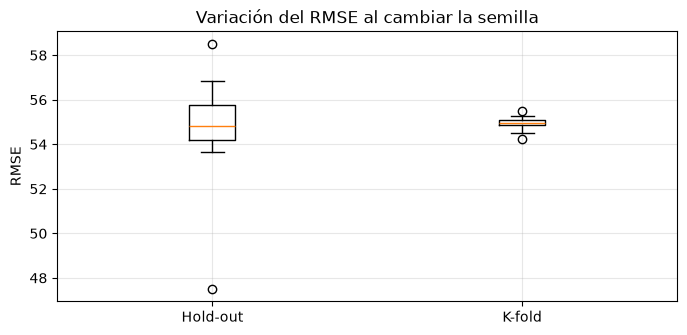

In [41]:
rmse_holdout = []
rmse_kfold = []

for semilla in range(20):
    # Hold-out
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=semilla
    )

    m = LinearRegression()
    m.fit(X_tr, y_tr)

    rmse_holdout.append(
        rmse(y_te, m.predict(X_te))
    )

    # K-fold
    kf_actual = KFold(
        n_splits=5,
        shuffle=True,
        random_state=semilla
    )

    errores = -cross_val_score(
        LinearRegression(),
        X,
        y,
        cv=kf_actual,
        scoring="neg_root_mean_squared_error"
    )

    rmse_kfold.append(errores.mean())

rmse_holdout = np.array(rmse_holdout)
rmse_kfold = np.array(rmse_kfold)

resumen = pd.DataFrame({
    "procedimiento": ["Hold-out", "K-fold"],
    "media": [
        rmse_holdout.mean(),
        rmse_kfold.mean()
    ],
    "desvio": [
        rmse_holdout.std(ddof=1),
        rmse_kfold.std(ddof=1)
    ]
})

display(resumen.round(3))

plt.boxplot(
    [rmse_holdout, rmse_kfold],
    tick_labels=["Hold-out", "K-fold"]
)

plt.ylabel("RMSE")
plt.title("Variación del RMSE al cambiar la semilla")
plt.show()

**Respuesta** 

La validación cruzada K-fold produce un resultado más estable al cambiar la semilla.

El hold-out obtuvo un RMSE medio de 54.832 y un desvío de 2.105. En cambio, K-fold obtuvo un RMSE medio similar, de 54.945, pero con un desvío mucho menor, de 0.273.

El boxplot también muestra que los resultados de hold-out están mucho más dispersos y presentan valores extremos, mientras que los resultados de K-fold están concentrados cerca de su media.

Esto sucede porque hold-out depende de una única división de los datos. En K-fold, cada resultado es el promedio de cinco folds y todas las observaciones participan en la validación, por lo que la influencia de una partición particular es menor.

### Ejercicio 16

Completar la tabla con lo observado en el laboratorio.

| Criterio | Hold-out | $K$-fold |
|---|---|---|
| Modelos que entrena | | |
| Estabilidad del resultado | | |
| Aprovechamiento de los datos | | |
| Costo de cómputo | | |
| Cuándo conviene | | |

Y responder en dos o tres líneas cada una:

1. Si el conjunto tuviera 50 observaciones en lugar de 442, **¿cuál de los dos
   procedimientos usarías?** Justificar con lo medido en el ejercicio 15.
2. Si entrenar el modelo llevara dos horas, ¿cambiaría la respuesta?
3. Un informe reporta «el modelo tiene un RMSE de 54,2». **¿Qué información falta**
   para que esa cifra sea interpretable?

**Respuestas**

| Criterio | Hold-out | K-fold |
|---|---|---|
| Modelos que entrena | 1 | K |
| Estabilidad del resultado | Menor; depende más de la partición | Mayor; promedia varias particiones |
| Aprovechamiento de los datos | Una parte queda reservada para prueba | Todas las observaciones validan una vez |
| Costo de cómputo | Bajo | Aproximadamente K veces mayor |
| Cuándo conviene | Muchos datos o modelos costosos | Pocos datos o cuando se necesita una estimación más estable |

1. Con 50 observaciones usaría K-fold porque aprovecha mejor los pocos datos disponibles y produce una estimación más estable.

2. Si cada entrenamiento demorara dos horas, el costo de K-fold sería importante. Usaría hold-out o un número pequeño de folds, según la precisión necesaria.

3. Falta indicar qué procedimiento de validación produjo el RMSE, el tamaño del conjunto de prueba o número de folds, la variabilidad del resultado, las unidades de la respuesta y el modelo de referencia con el cual se compara.

---

## Cierre

Lo que este laboratorio deja instalado:

- **`train_test_split`** parte una vez, al azar. Es rápido y su resultado depende del
  sorteo.
- **`KFold` + `cross_val_score`** parten $K$ veces, usan todas las observaciones para
  validar y devuelven $K$ números.
- **Nunca se reporta la media sola.** Un error estimado sin su variabilidad no dice si la
  diferencia entre dos modelos es real o es el sorteo.
- **El error medido sobre los datos de entrenamiento no sirve** como estimación del
  desempeño: en promedio es optimista.
- **Un imputador, un escalador y un codificador estiman parámetros igual que un modelo.**
  Por eso se ajustan sobre la parte de entrenamiento y se aplican, ya ajustados, sobre el
  resto.
- **El `Pipeline` no es una comodidad de biblioteca**: es la estructura que impide escribir
  la fuga. La validación cruzada envuelve al flujo completo, nunca al revés.
- **Los coeficientes se leen con sus nombres.** `coef_` es un arreglo sin etiquetas, y en
  un flujo los nombres los da `get_feature_names_out` del preparador.